<div align="center">

# Predictive Log Anomaly Engine
## GPU Execution Path — Optional Advanced Runtime

*Standard CPU pipeline is production-ready &nbsp;·&nbsp; GPU adds throughput at scale &nbsp;·&nbsp; Same models, same architecture*

---

</div>

| Property | Details |
|:---|:---|
| **GPU Status** | Optional advanced runtime path |
| **CPU Status** | Recommended default — fully production-ready |
| **Framework** | PyTorch (CUDA-compatible) |
| **GPU-Accelerated Stages** | LSTM Behavior Model · Autoencoder Detector |
| **CPU-Only Stages** | Tokenization · Word2Vec Lookup · Alert Manager |
| **Performance Figures** | All conceptual / illustrative — not measured benchmarks |
| **Model Portability** | All models run on CPU and GPU — no architecture change |


## Table of Contents

1. [GPU Extension Overview](#1-gpu-extension-overview)
2. [Why GPU Can Matter](#2-why-gpu-can-matter)
3. [Relationship to the Main System](#3-relationship-to-the-main-system)
4. [Execution Path Comparison](#4-execution-path-comparison)
5. [Runtime Considerations](#5-runtime-considerations)
6. [Throughput Scaling — Conceptual View](#6-throughput-scaling)
7. [Tradeoffs](#7-tradeoffs)
8. [GPU Applicability per Pipeline Stage](#8-gpu-applicability)
9. [When GPU Helps](#9-when-gpu-helps)
10. [When the Standard Runtime Is Enough](#10-when-standard-runtime-is-enough)
11. [Deployment Positioning](#11-deployment-positioning)
12. [Portfolio Value](#12-portfolio-value)
13. [Final Summary](#13-final-summary)


---

## 1. GPU Extension Overview

The Predictive Log Anomaly Engine is built on **PyTorch** — which means every model in the V2 pipeline is inherently GPU-compatible. The LSTM Behavior Model and the Autoencoder Detector can be targeted to a CUDA device with a single `.to(device)` call, with no changes to model architecture, training code, or inference logic.

This notebook explores GPU as an **optional advanced execution path** — a natural extension of the existing system rather than a separate product. The intent is to:

1. Clarify exactly which stages benefit from GPU acceleration
2. Provide a conceptual view of the throughput scaling dynamics
3. Frame the deployment decision honestly — when GPU helps, and when it is unnecessary overhead
4. Demonstrate GPU awareness as a dimension of ML engineering depth

> **Important:** All performance figures in this notebook are **conceptual illustrations** of general GPU scaling behaviour. They are not derived from measured production benchmarks.


---

## 2. Why GPU Can Matter

GPUs provide massive parallel compute — thousands of small cores operating simultaneously on matrix operations. This architecture aligns well with deep learning inference when:

- **Batch sizes are large** — GPU parallelism is amortised across many samples
- **Operations are matrix-heavy** — LSTM hidden state updates and autoencoder reconstruction are dense linear algebra
- **Throughput requirements are high** — high-frequency log streams demand fast window-by-window scoring

| Condition | CPU Adequate? | GPU Beneficial? |
|:---|:---:|:---:|
| Batch size = 1 (real-time per-event) | ✅ Yes | ⚠ Marginal (transfer overhead) |
| Batch size = 32–256 (bulk scoring) | ⚠ Possible | ✅ Significant gain |
| High-freq stream (>1000 events/sec) | ⚠ Depends | ✅ Recommended evaluation |
| Standard production log volume | ✅ Yes | ⚠ Overkill |
| Offline bulk evaluation | ✅ Possible | ✅ Recommended |


---

## 3. Relationship to the Main System

GPU is an **additive capability** — not a replacement for, or a prerequisite to, the standard CPU runtime.

```
Standard System (CPU)
└─ Fully functional production system
└─ All four V2 pipeline stages
└─ Sub-10 ms end-to-end latency per window
└─ Recommended for all typical deployments

GPU Extension (Optional)
└─ Same models — torch.device('cuda') targeting
└─ LSTM + Autoencoder on CUDA device
└─ Tokenization + AlertManager remain CPU-bound
└─ Beneficial at high batch size or extreme throughput
```

The training pipeline, model artifacts, API layer, observability stack, and alert system are **identical** between CPU and GPU runtime paths. The only change is device placement for the two compute-intensive neural stages.


In [1]:
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch

# ── Colour palette ────────────────────────────────────────────────────────────
BLUE      = '#2563EB'
GREEN     = '#16A34A'
AMBER     = '#D97706'
RED       = '#DC2626'
PURPLE    = '#7C3AED'
GRAY      = '#6B7280'
DARK      = '#111827'
LIGHT     = '#F9FAFB'
BORDER    = '#E5E7EB'
GPU_COLOR = '#22C55E'   # GPU path — bright green
CPU_COLOR = '#3B82F6'   # CPU path — blue

plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    LIGHT,
    'axes.edgecolor':    BORDER,
    'axes.grid':         True,
    'grid.alpha':        0.35,
    'grid.color':        '#D1D5DB',
    'font.family':       'DejaVu Sans',
    'font.size':         11,
    'axes.labelsize':    11,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.titlepad':     12,
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'legend.fontsize':   9.5,
    'legend.framealpha': 0.85,
    'legend.edgecolor':  BORDER,
})

def spine_clean(ax, keep=('left', 'bottom')):
    for s in ('top', 'right', 'left', 'bottom'):
        ax.spines[s].set_visible(s in keep)

print('Environment ready  ✓')
print(f'matplotlib {matplotlib.__version__}  |  numpy {np.__version__}')


Environment ready  ✓
matplotlib 3.10.8  |  numpy 2.4.1


---

## 4. Execution Path Comparison

The diagram below shows the V2 inference pipeline on both execution paths. Stages highlighted in **green** are where GPU acceleration applies. Stages in **blue** are CPU-bound regardless of runtime target.


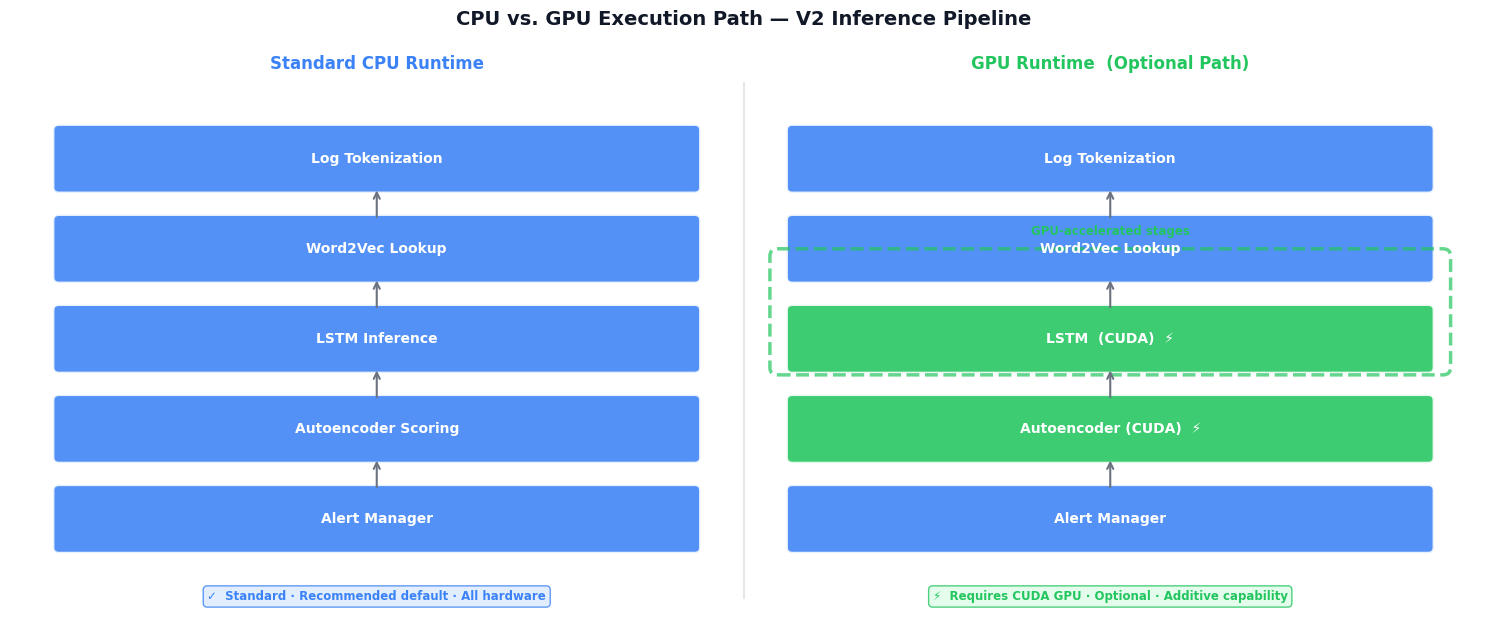

In [2]:
fig, ax = plt.subplots(figsize=(15, 6.5))
ax.set_xlim(0, 15)
ax.set_ylim(0, 6.5)
ax.axis('off')
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

# Column headers
ax.text(3.75, 6.2, 'Standard CPU Runtime', ha='center', fontsize=12,
        fontweight='bold', color=CPU_COLOR)
ax.text(11.25, 6.2, 'GPU Runtime  (Optional Path)', ha='center', fontsize=12,
        fontweight='bold', color=GPU_COLOR)
ax.axvline(7.5, color=BORDER, linewidth=1.5, ymin=0.05, ymax=0.93)

cpu_stages = [
    ('Log Tokenization',    CPU_COLOR, False),
    ('Word2Vec Lookup',     CPU_COLOR, False),
    ('LSTM Inference',      CPU_COLOR, False),
    ('Autoencoder Scoring', CPU_COLOR, False),
    ('Alert Manager',       CPU_COLOR, False),
]
gpu_stages = [
    ('Log Tokenization',    CPU_COLOR, False),
    ('Word2Vec Lookup',     CPU_COLOR, False),
    ('LSTM  (CUDA)',        GPU_COLOR, True),
    ('Autoencoder (CUDA)',  GPU_COLOR, True),
    ('Alert Manager',       CPU_COLOR, False),
]

for i, (label, color, _accel) in enumerate(cpu_stages):
    y = 5.2 - i * 1.0
    r = FancyBboxPatch((0.5, y - 0.32), 6.5, 0.64,
                       boxstyle='round,pad=0.06',
                       facecolor=color, edgecolor='white', linewidth=2, alpha=0.88)
    ax.add_patch(r)
    ax.text(3.75, y, label, ha='center', va='center',
            fontsize=10, color='white', fontweight='bold')
    if i < len(cpu_stages) - 1:
        ax.annotate('', xy=(3.75, y - 0.32), xytext=(3.75, y - 0.68),
                    arrowprops=dict(arrowstyle='->', color=GRAY, lw=1.5))

for i, (label, color, accel) in enumerate(gpu_stages):
    y = 5.2 - i * 1.0
    r = FancyBboxPatch((8.0, y - 0.32), 6.5, 0.64,
                       boxstyle='round,pad=0.06',
                       facecolor=color, edgecolor='white', linewidth=2, alpha=0.88)
    ax.add_patch(r)
    suffix = '  ⚡' if accel else ''
    ax.text(11.25, y, label + suffix, ha='center', va='center',
            fontsize=10, color='white', fontweight='bold')
    if i < len(gpu_stages) - 1:
        ax.annotate('', xy=(11.25, y - 0.32), xytext=(11.25, y - 0.68),
                    arrowprops=dict(arrowstyle='->', color=GRAY, lw=1.5))

# GPU acceleration badge
ax.add_patch(FancyBboxPatch((7.85, 2.88), 6.80, 1.24,
                             boxstyle='round,pad=0.08',
                             facecolor='none', edgecolor=GPU_COLOR,
                             linewidth=2.5, linestyle='--', alpha=0.7))
ax.text(11.25, 4.35, 'GPU-accelerated stages', ha='center', fontsize=8.5,
        color=GPU_COLOR, fontweight='bold')

# Bottom badges
ax.text(3.75, 0.30, '✓  Standard · Recommended default · All hardware',
        ha='center', fontsize=8.5, color=CPU_COLOR, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.35', facecolor='#DBEAFE',
                  edgecolor=CPU_COLOR, alpha=0.8))
ax.text(11.25, 0.30, '⚡  Requires CUDA GPU · Optional · Additive capability',
        ha='center', fontsize=8.5, color=GPU_COLOR, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.35', facecolor='#DCFCE7',
                  edgecolor=GPU_COLOR, alpha=0.8))

ax.set_title('CPU vs. GPU Execution Path — V2 Inference Pipeline',
             fontsize=14, fontweight='bold', color=DARK)
plt.tight_layout()
plt.show()


---

## 5. Runtime Considerations

| Consideration | Detail |
|:---|:---|
| **Device targeting** | `torch.device('cuda')` or `torch.device('cpu')` — set at model initialisation |
| **CUDA requirement** | CUDA-capable GPU + compatible PyTorch build (e.g. `torch+cu121`) |
| **No architecture change** | Same model classes, same weights — only device changes |
| **Data transfer overhead** | Input tensors must be moved to the GPU device before inference |
| **Batch size matters** | At batch=1, data transfer may dominate; GPU advantage emerges at batch=16+ |
| **Memory requirements** | GPU VRAM must accommodate model weights + batch tensors |
| **Deployment** | Set `CUDA_VISIBLE_DEVICES` env var to control device selection |
| **Mixed precision** | `torch.autocast` can be applied for FP16 inference on supported hardware |

**Enabling GPU inference in practice:**

```python
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load model and move to device
behavior_model = SystemBehaviorModel(...).to(device)
anomaly_detector = AnomalyDetector(...).to(device)

# At inference time — move input to device
window_tensor = window_tensor.to(device)
context_vector = behavior_model(window_tensor)
anomaly_score  = anomaly_detector(context_vector)
```

The system already uses `torch.device` throughout its codebase. GPU targeting requires no model changes — only device configuration at startup.


---

## 6. Throughput Scaling — Conceptual View

The chart below illustrates the **general shape** of CPU vs. GPU throughput scaling as batch size increases. These curves represent the characteristic behaviour of compute-bound neural inference — not measured numbers from this specific system.


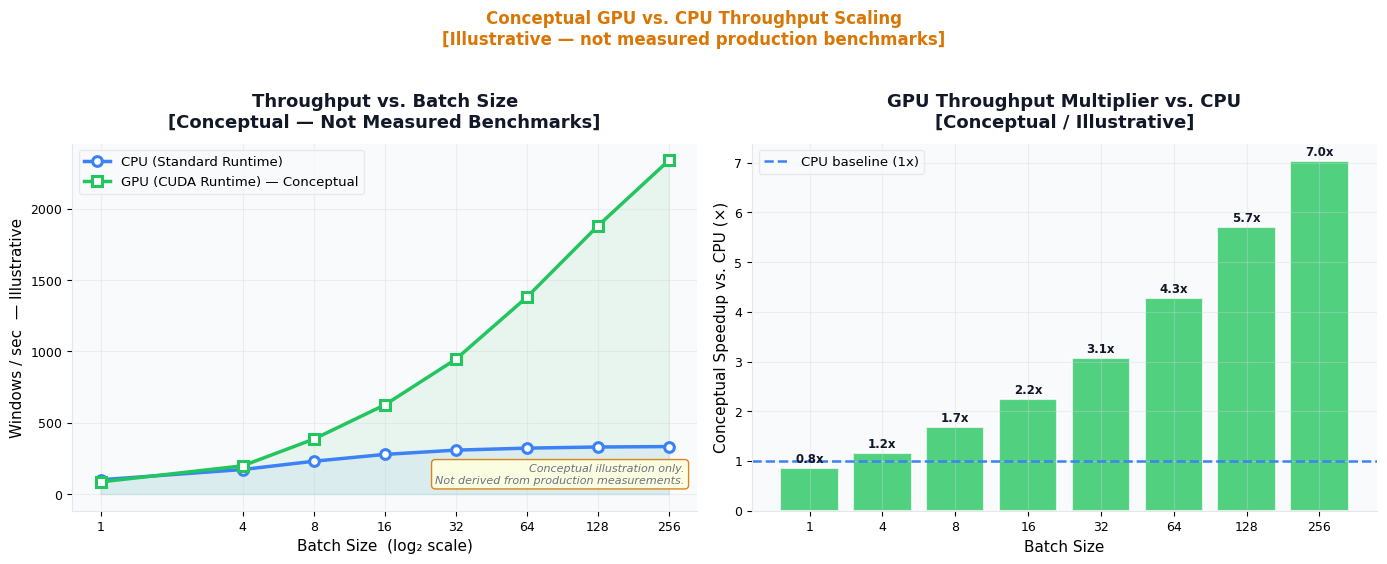

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.patch.set_facecolor('white')

# ── Left: Throughput vs batch size ────────────────────────────────────────────
ax = axes[0]
batch_sizes    = [1, 4, 8, 16, 32, 64, 128, 256]
cpu_throughput = [100, 172, 230, 278, 308, 322, 330, 333]
gpu_throughput = [85,  198, 385, 625, 945, 1380, 1880, 2340]

ax.plot(batch_sizes, cpu_throughput, 'o-', color=CPU_COLOR, linewidth=2.5,
        markersize=7, label='CPU (Standard Runtime)',
        markerfacecolor='white', markeredgewidth=2.2)
ax.plot(batch_sizes, gpu_throughput, 's-', color=GPU_COLOR, linewidth=2.5,
        markersize=7, label='GPU (CUDA Runtime) — Conceptual',
        markerfacecolor='white', markeredgewidth=2.2)
ax.fill_between(batch_sizes, cpu_throughput, alpha=0.08, color=CPU_COLOR)
ax.fill_between(batch_sizes, gpu_throughput, alpha=0.08, color=GPU_COLOR)

ax.set_xscale('log', base=2)
ax.set_xticks(batch_sizes)
ax.set_xticklabels([str(b) for b in batch_sizes])
ax.set_xlabel('Batch Size  (log\u2082 scale)')
ax.set_ylabel('Windows / sec  — Illustrative')
ax.set_title('Throughput vs. Batch Size\n[Conceptual — Not Measured Benchmarks]', color=DARK)
ax.legend(loc='upper left')
ax.text(0.98, 0.07,
        'Conceptual illustration only.\nNot derived from production measurements.',
        transform=ax.transAxes, ha='right', va='bottom',
        fontsize=8, color=GRAY, style='italic',
        bbox=dict(boxstyle='round,pad=0.35', facecolor='lightyellow',
                  edgecolor=AMBER, alpha=0.9))
spine_clean(ax)

# ── Right: GPU advantage multiplier across batch sizes ────────────────────────
ax2 = axes[1]
speedup = [g / c for g, c in zip(gpu_throughput, cpu_throughput)]

bars = ax2.bar(range(len(batch_sizes)), speedup, color=GPU_COLOR, alpha=0.78,
               edgecolor='white', linewidth=1.5)
ax2.axhline(1.0, color=CPU_COLOR, linewidth=1.8, linestyle='--',
            label='CPU baseline (1x)')
for bar, val in zip(bars, speedup):
    ax2.text(bar.get_x() + bar.get_width() / 2, val + 0.05,
             f'{val:.1f}x', ha='center', va='bottom',
             fontsize=8.5, fontweight='bold', color=DARK)

ax2.set_xticks(range(len(batch_sizes)))
ax2.set_xticklabels([str(b) for b in batch_sizes])
ax2.set_xlabel('Batch Size')
ax2.set_ylabel('Conceptual Speedup vs. CPU (\xd7)')
ax2.set_title('GPU Throughput Multiplier vs. CPU\n[Conceptual / Illustrative]', color=DARK)
ax2.legend(loc='upper left')
spine_clean(ax2)

plt.suptitle('Conceptual GPU vs. CPU Throughput Scaling\n'
             '[Illustrative — not measured production benchmarks]',
             fontsize=12, fontweight='bold', color=AMBER, y=1.02)
plt.tight_layout()
plt.show()


---

## 7. Tradeoffs

Choosing GPU runtime is an engineering tradeoff — not a default upgrade. The considerations below should inform that decision:

### Advantages of GPU Runtime

- **Higher throughput at large batch sizes** — matrix operations parallelise across thousands of CUDA cores
- **Lower latency at scale** — when the pipeline must score many windows per second simultaneously
- **Offline bulk evaluation** — re-scoring historical log archives benefits significantly from GPU
- **Future model scaling** — larger LSTM hidden dimensions or deeper autoencoders are more viable on GPU

### Disadvantages / Risks

- **Infrastructure cost** — GPU instances are more expensive than CPU in cloud environments
- **Data transfer overhead** — at `batch_size=1`, CPU-GPU tensor transfer may dominate and negate gains
- **Dependency complexity** — CUDA drivers, CUDA-compatible PyTorch builds, and driver/toolkit versioning
- **Operational overhead** — GPU health monitoring, driver updates, OOM error handling
- **Not necessary** for typical production log volumes — standard CPU runtime is perfectly adequate

> **Recommendation:** Start with the CPU runtime. Evaluate GPU only when throughput requirements demonstrably exceed CPU capacity — and measure before deciding.


---

## 8. GPU Applicability per Pipeline Stage


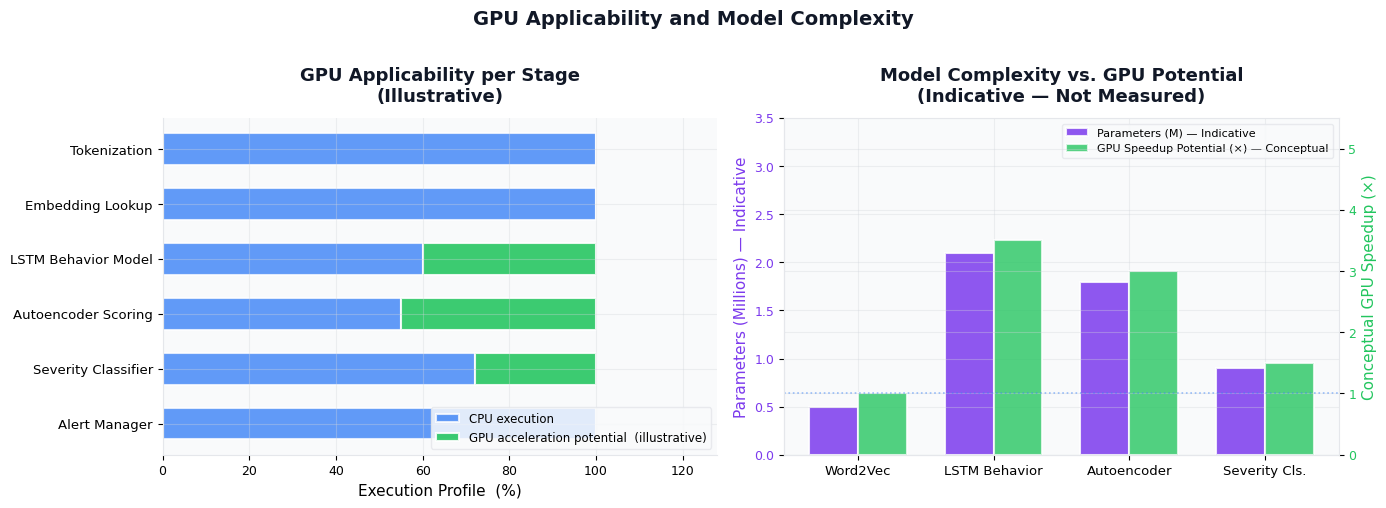

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('white')

# ── Left: GPU applicability bar chart ─────────────────────────────────────────
ax = axes[0]
stages   = ['Alert Manager', 'Severity Classifier',
            'Autoencoder Scoring', 'LSTM Behavior Model',
            'Embedding Lookup', 'Tokenization']
cpu_pct  = [100, 72,  55,  60,  100, 100]
gpu_pct  = [0,   28,  45,  40,  0,   0  ]
y        = range(len(stages))

ax.barh(y, cpu_pct, color=CPU_COLOR, height=0.58,
        edgecolor='white', linewidth=1.5, alpha=0.80, label='CPU execution')
ax.barh(y, gpu_pct, left=cpu_pct, color=GPU_COLOR, height=0.58,
        edgecolor='white', linewidth=1.5, alpha=0.88,
        label='GPU acceleration potential  (illustrative)')

ax.set_yticks(y)
ax.set_yticklabels(stages, fontsize=9.5)
ax.set_xlabel('Execution Profile  (%)')
ax.set_title('GPU Applicability per Stage\n(Illustrative)', color=DARK)
ax.legend(loc='lower right', fontsize=8.5)
ax.set_xlim(0, 128)
spine_clean(ax)

# ── Right: Model complexity overview ─────────────────────────────────────────
ax2 = axes[1]
models   = ['Word2Vec', 'LSTM Behavior', 'Autoencoder', 'Severity Cls.']
params_m = [0.5, 2.1, 1.8, 0.9]
gpu_mult = [1.0, 3.5, 3.0, 1.5]
x        = np.arange(len(models))
width    = 0.36

bars1 = ax2.bar(x - width / 2, params_m, width,
                label='Parameters (M) — Indicative',
                color=PURPLE, edgecolor='white', linewidth=1.5, alpha=0.85)
ax3   = ax2.twinx()
bars2 = ax3.bar(x + width / 2, gpu_mult, width,
                label='GPU Speedup Potential (\xd7) — Conceptual',
                color=GPU_COLOR, edgecolor='white', linewidth=1.5, alpha=0.78)
ax3.axhline(1.0, color=CPU_COLOR, linewidth=1.2, linestyle=':', alpha=0.5)
ax3.set_ylabel('Conceptual GPU Speedup (\xd7)', color=GPU_COLOR)
ax3.tick_params(axis='y', labelcolor=GPU_COLOR)
ax3.set_ylim(0, 5.5)

ax2.set_xticks(x)
ax2.set_xticklabels(models, fontsize=9.5)
ax2.set_ylabel('Parameters (Millions) — Indicative', color=PURPLE)
ax2.tick_params(axis='y', labelcolor=PURPLE)
ax2.set_ylim(0, 3.5)
ax2.set_title('Model Complexity vs. GPU Potential\n(Indicative — Not Measured)', color=DARK)

h1, l1 = ax2.get_legend_handles_labels()
h2, l2 = ax3.get_legend_handles_labels()
ax2.legend(h1 + h2, l1 + l2, loc='upper right', fontsize=8)
spine_clean(ax2)

plt.suptitle('GPU Applicability and Model Complexity',
             fontsize=14, fontweight='bold', color=DARK, y=1.01)
plt.tight_layout()
plt.show()


---

## 9. When GPU Helps

GPU acceleration provides genuine value in these scenarios:

**High-throughput streaming**
- Log volumes exceeding several hundred events per second per process
- Latency SLA requirements that CPU inference cannot meet at the required throughput

**Bulk offline scoring**
- Re-evaluating large historical archives against new model versions
- Batch evaluation scripts (`scripts/evaluate_v2.py`) with `--max-sessions` in the thousands
- Model fine-tuning or re-training passes on GPU-attached training nodes

**Research and experimentation**
- Experimenting with larger LSTM hidden dimensions or deeper autoencoder architectures
- Testing ensemble configurations at high batch sizes
- Rapid iteration on model variants during development

**Multi-tenant or multi-stream deployments**
- Single GPU serving many independent log streams in parallel via batched inference
- Consolidated inference servers for multi-service observability platforms


---

## 10. When the Standard Runtime Is Enough

For the majority of real-world deployments, the **CPU runtime is the correct and sufficient choice**:

| Scenario | Recommendation |
|:---|:---|
| Single-service log monitoring | ✅ Standard CPU |
| Moderate log volume (< 500 events/sec) | ✅ Standard CPU |
| Real-time per-event inference (batch=1) | ✅ Standard CPU |
| Development and testing environments | ✅ Standard CPU |
| Cost-sensitive deployments | ✅ Standard CPU |
| Docker Compose demo stack | ✅ Standard CPU |
| Edge / embedded deployments | ✅ Standard CPU |

The V2 pipeline achieves **sub-10ms end-to-end latency per window** on standard CPU hardware. For most production workloads — including typical HDFS, microservice, or application log monitoring — this is well within acceptable operating bounds.

> **The engine is not GPU-dependent.** GPU is an optional capability that extends the performance envelope, not a requirement for correct or complete operation.


---

## 11. Deployment Positioning

| Deployment Scenario | Runtime | Notes |
|:---|:---|:---|
| **Docker Compose (demo)** | CPU | `docker/docker-compose.yml` — standard |
| **Docker Compose (production)** | CPU | `docker/docker-compose.prod.yml` |
| **GPU-enabled container** | CUDA | Set `CUDA_VISIBLE_DEVICES`, install `torch+cuXXX` |
| **Cloud VM inference** | CPU or GPU | Evaluate based on throughput requirements |
| **Kubernetes pod** | CPU or GPU | GPU pods require node selectors + resource requests |
| **Offline evaluation** | GPU recommended | `scripts/evaluate_v2.py` with high `--max-sessions` |

**Enabling GPU in Docker:**

```yaml
# In docker-compose override:
services:
  api:
    deploy:
      resources:
        reservations:
          devices:
            - driver: nvidia
              count: 1
              capabilities: [gpu]
    environment:
      - CUDA_VISIBLE_DEVICES=0
```


---

## 12. Portfolio Value

The GPU capability of this project demonstrates several dimensions of ML engineering depth:

| Dimension | What It Shows |
|:---|:---|
| **Framework fluency** | Native PyTorch — CUDA-compatible models by default |
| **Architecture awareness** | Knowing which pipeline stages benefit from GPU and which don't |
| **Engineering judgement** | Honest tradeoff framing — GPU is optional, not mandatory |
| **Deployment awareness** | Understanding containerised GPU deployment constraints |
| **MLOps breadth** | Training pipeline + inference serving + GPU consideration = full lifecycle |
| **Honest evaluation** | No invented benchmarks — conceptual framing is credible and defensible |

The ability to say *"GPU is available as an optional path, here is exactly where it applies, here is when it is worth it, and here is how you enable it"* is a mark of system-level thinking rather than surface-level familiarity.

This is what distinguishes portfolio work that has been thought through from work that has merely been assembled.


---

## 13. Final Summary

**GPU is an optional extension of a system that works correctly without it.**

The Predictive Log Anomaly Engine's V2 pipeline is built on PyTorch — which means GPU support is structurally present throughout the codebase. Enabling it for the compute-intensive LSTM and Autoencoder stages is a configuration change, not an architectural one.

Whether to use GPU in production depends on a clear evaluation of throughput requirements, deployment cost, and operational overhead. For most workloads, the CPU runtime delivers sub-10ms latency with no GPU dependency. For high-volume streaming, bulk evaluation, or research workloads, GPU offers a natural and accessible acceleration path.

The right engineering answer is: **measure first, decide accordingly**.

---

<div align="center">

*Predictive Log Anomaly Engine v2  ·  PyTorch (CUDA-compatible)  ·  LSTM + Autoencoder*

*GPU as Optional Acceleration  ·  CPU Runtime is Production-Ready*

</div>
